In [5]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.append('..')
import src.consNfextendedHubbard
import importlib
importlib.reload(src.consNfextendedHubbard)
from src.consNfextendedHubbard import _report_idmrg
from tenpy.models.model import CouplingMPOModel
from tenpy.networks.site import SpinHalfFermionSite
import src.observables as obs
import src.avg_observables as avobs
import logging 
logging.basicConfig(level=logging.INFO)
from tenpy.networks.mps import MPS
from tenpy.networks.site import SpinHalfFermionSite
from tenpy.algorithms import dmrg as tenpy_dmrg
import utils.io as io
import tenpy
print(tenpy.__version__)
DATADIR = '../../data/iDMRG/'
from scipy.fftpack import fft, ifft, fftfreq, fftshift

1.1.0


In [4]:
# psi, results = io.load_mps_with_metadata('lastVpm_3.800_chi500.h5')
# psi, results = io.load_mps_with_metadata('ff_chi80.h5')
loadfile = os.path.join(DATADIR, "Vpm3.8cc/Vpm_3.800_chi1000.h5")
# loadfile = os.path.join(DATADIR, 'ffcc/ff_chi500.h5')
psi, results = io.load_mps_with_metadata(loadfile)
print('Correlation length = ', psi.correlation_length2())
diags = results["diagnostics"]

Correlation length =  185.7962207372356


In [6]:
distrange = 200 #picked smaller than correlation length
chargecorr = obs.denoise_rolling(np.abs(obs.charge_corr(psi, distrange, connected=True)), window=1)
spinzcorr = obs.denoise_rolling(np.abs(obs.SzSz_corr(psi, distrange, connected=True)), window=1)
spinpmcorr = obs.denoise_rolling(np.abs(obs.SpSm_corr(psi, distrange)), window=1)
electroncorr = obs.denoise_rolling(np.abs(obs.electron_corr(psi, distrange, "tot")), window=1)

In [7]:
alt_chargecorr = avobs.connected_charge_correlations_avg(psi, distrange)
alt_spinzcorr = avobs.connected_sz_correlations_avg(psi, distrange)
alt_spinpmcorr = avobs.sp_sm_correlations_avg(psi, distrange)
alt_fermioncorr = avobs.green_function_down_avg(psi, distrange)

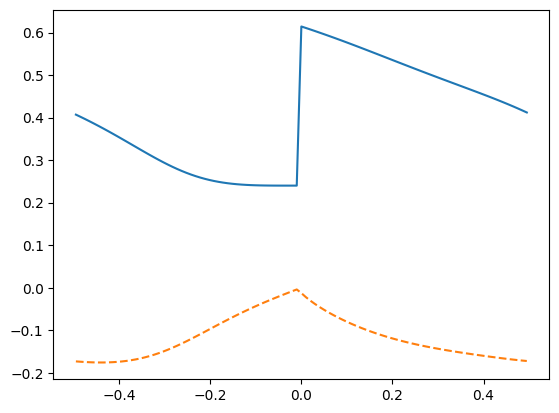

In [ ]:
freqs = fftshift(fftfreq(99))
fftval = fftshift (fft(chargecorr)[1:100])
plt.plot(freqs, fftval.real)
plt.plot(freqs, fftval.imag, ls='--')